<a href="https://colab.research.google.com/github/XiaoLiang28/Datamanagement/blob/main/Final_Code_Xiao_Liang.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Model 1 final coverage: 0.9932


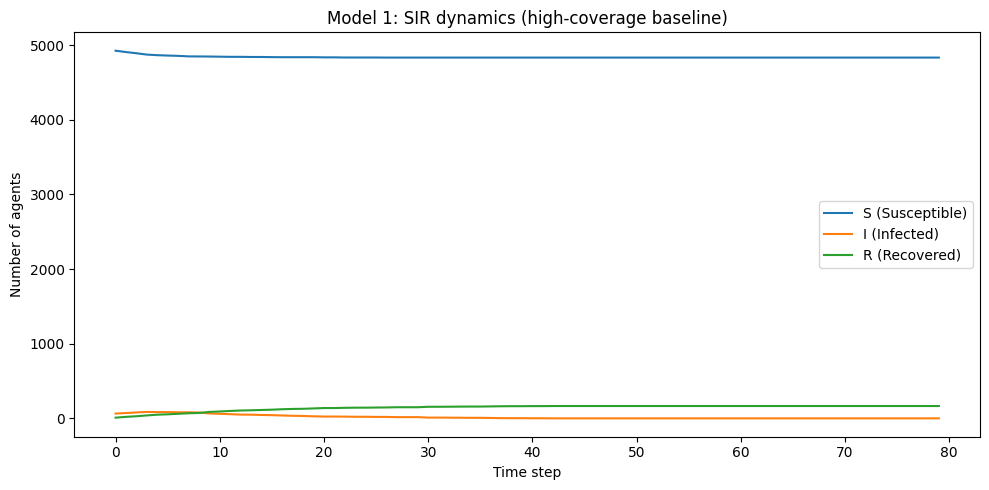

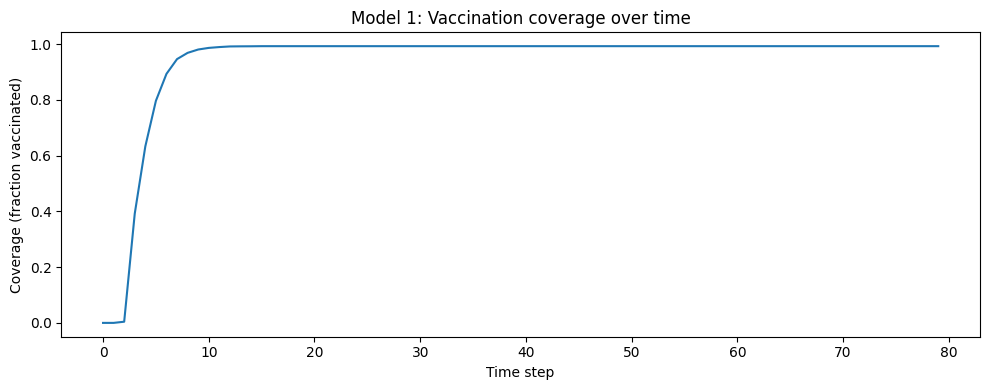


=== Model 2, T = 30 ===
Final coverage (general_only): 0.301
Final coverage (hpv_only):     0.580
Coverage by education (general_only): {0: 0.25311475409836065, 1: 0.3072289156626506, 2: 0.3604060913705584}
Coverage by education (hpv_only):     {0: 0.5447316103379721, 1: 0.5815173527037933, 2: 0.6278381046396841}
Coverage by urban (general_only):     {0: 0.28093306288032455, 1: 0.3143989431968296}
Coverage by urban (hpv_only):         {0: 0.5639506172839506, 1: 0.5905882352941176}


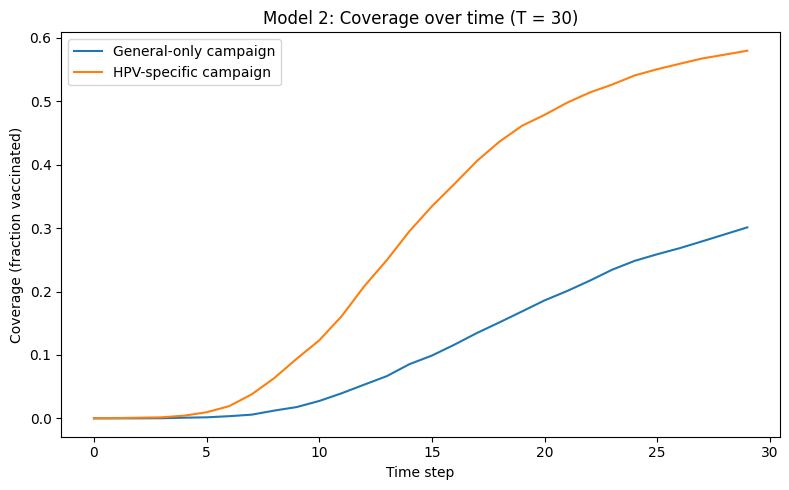

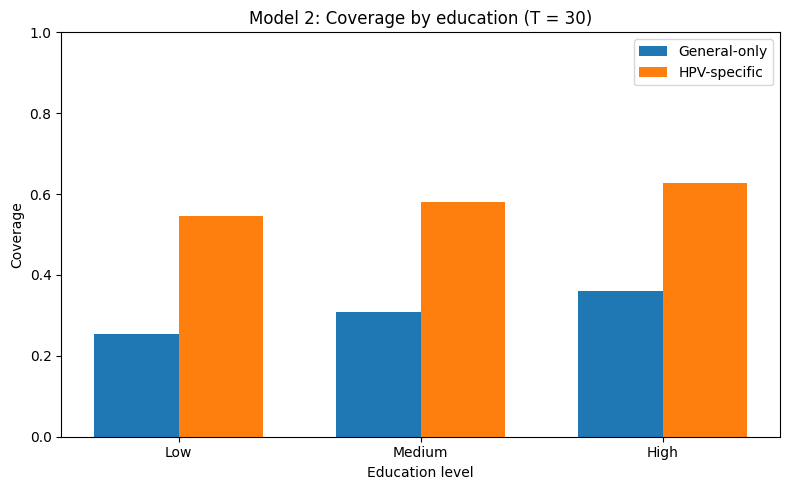

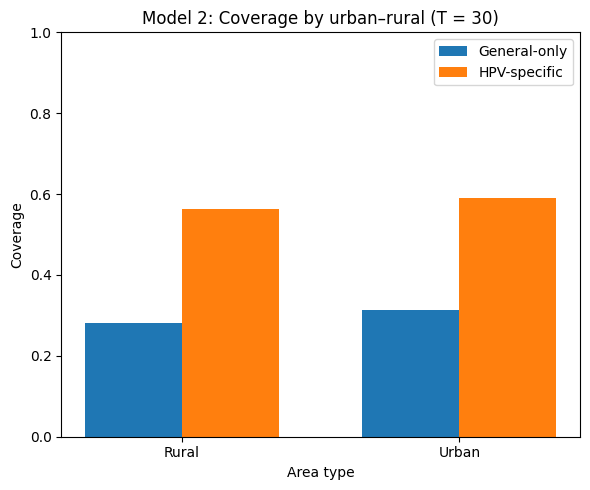


=== Model 2, T = 50 ===
Final coverage (general_only): 0.404
Final coverage (hpv_only):     0.593
Coverage by education (general_only): {0: 0.3811141304347826, 1: 0.40340459224069675, 2: 0.43812375249500995}
Coverage by education (hpv_only):     {0: 0.578700602813128, 1: 0.5955100433241434, 2: 0.609504132231405}
Coverage by urban (general_only):     {0: 0.40804020100502514, 1: 0.4009966777408638}
Coverage by urban (hpv_only):         {0: 0.5886929460580913, 1: 0.5960286458333334}


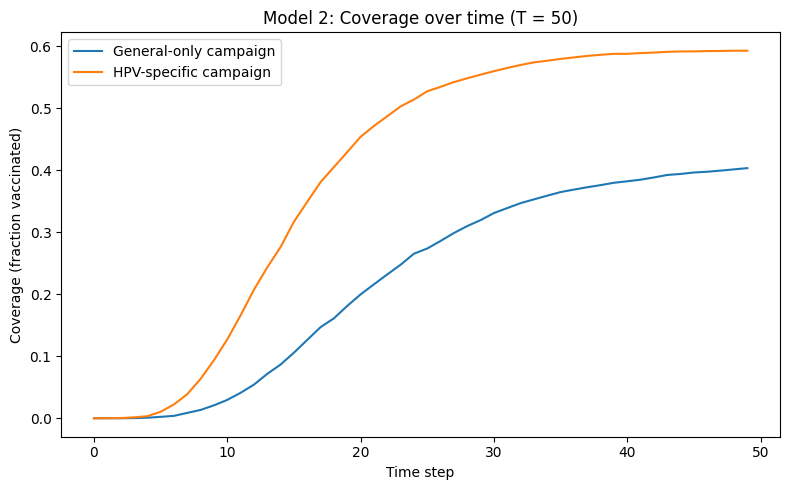

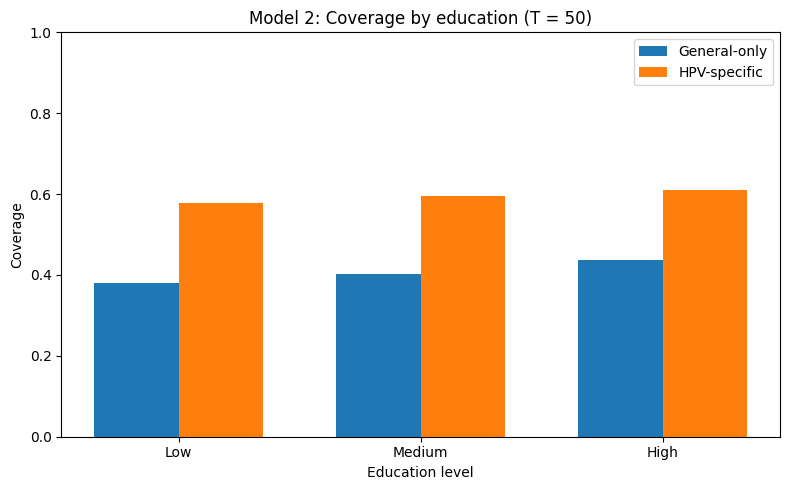

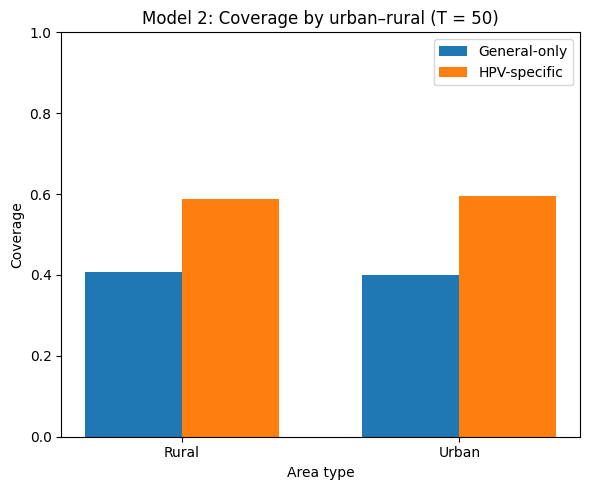


=== Model 2, T = 80 ===
Final coverage (general_only): 0.401
Final coverage (hpv_only):     0.631
Coverage by education (general_only): {0: 0.39037433155080214, 1: 0.38963142972863507, 2: 0.4444444444444444}
Coverage by education (hpv_only):     {0: 0.6246630727762803, 1: 0.6243072050673001, 2: 0.6555555555555556}
Coverage by urban (general_only):     {0: 0.3885318833415719, 1: 0.4098085320792744}
Coverage by urban (hpv_only):         {0: 0.6207584830339321, 1: 0.6371829105473965}


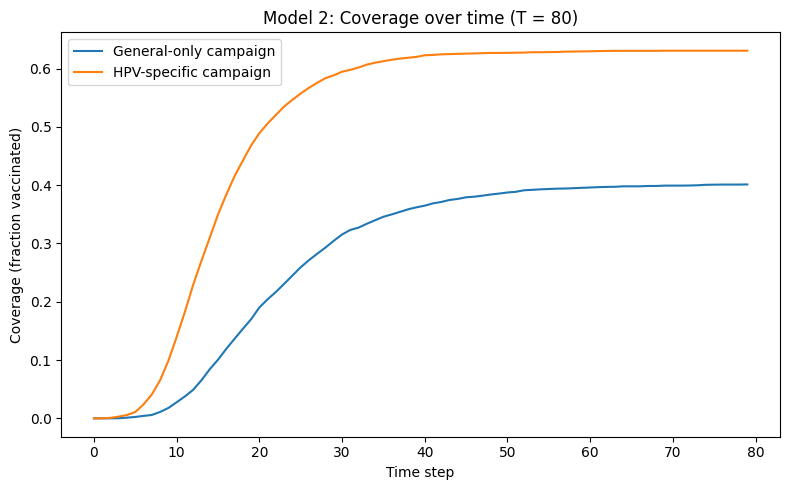

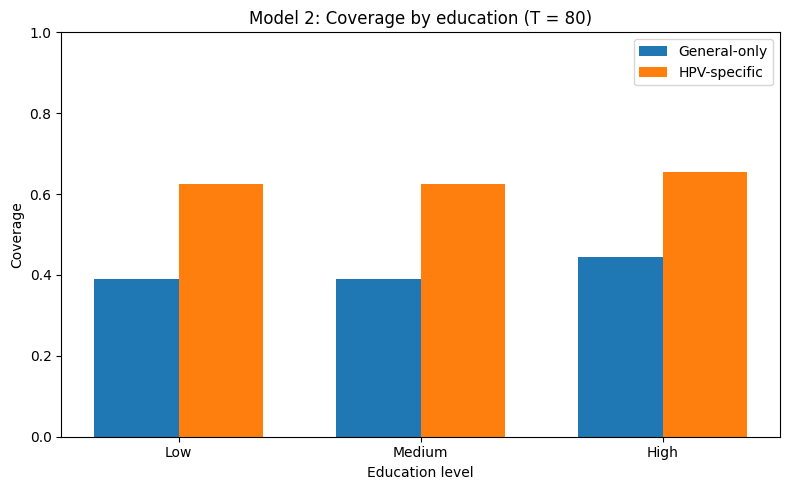

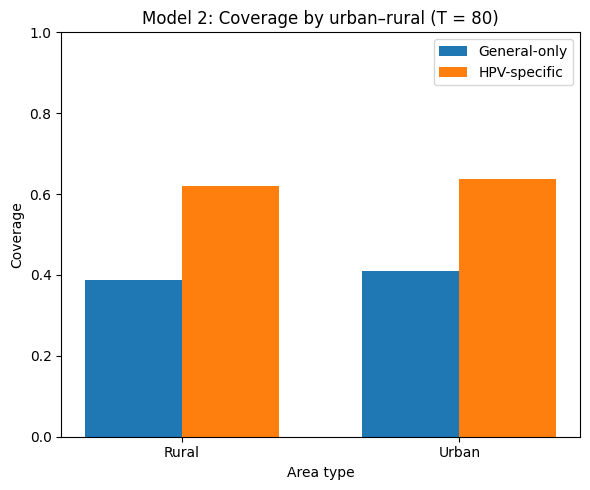

In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt



N = 5000              # number of agents
T_MODEL1 = 80         # number of time steps for Model 1

K = 6                 # average degree in small-world network
P_REWIRE = 0.1        # rewiring probability

# Small-world network building
G = nx.watts_strogatz_graph(N, K, P_REWIRE)
neighbors = {i: list(G.neighbors(i)) for i in G.nodes()}



# Model 1: High-coverage baseline model


def run_model1():

    np.random.seed(0)

    # Parameters for model 1
    alpha_G = 0.2       # sensitivity to government information
    G_strength = 1.0    # strength of government campaign each step

    p_misinfo_seed = 0.02   # initial proportion of misinformation sources
    alpha_M = 0.3           # sensitivity to negative information
    w_negative = 0.2        # weight per misinformation neighbor per step

    theta = 0.65             # desire threshold for vaccination
    p_vax = 0.5             # probability of vaccinating if desire >= theta

    beta = 0.05             # per-contact infection probability
    gamma = 0.1             # recovery probability per time step
    vaccine_efficacy = 0.9  # reduction in infection risk for vaccinated agents

    p_side_effect = 0.001   # rare side effect probability

    # States
    health = np.zeros(N, dtype=np.int8)   # 0=S, 1=I, 2=R
    vax = np.zeros(N, dtype=np.int8)      # 0=unvaccinated, 1=vaccinated
    desire = np.random.normal(loc=0.2, scale=0.05, size=N)
    desire = np.clip(desire, 0.0, 1.0)

    misinfo = (np.random.rand(N) < p_misinfo_seed)

    # Seed initial infections (about 1%)
    initial_infected = max(1, N // 100)
    infected_indices = np.random.choice(N, size=initial_infected, replace=False)
    health[infected_indices] = 1

    # Time series storage
    S_list, I_list, R_list = [], [], []
    coverage_list = []
    avg_desire_list = []
    misinfo_count_list = []

    def record_stats():
        S_list.append(np.sum(health == 0))
        I_list.append(np.sum(health == 1))
        R_list.append(np.sum(health == 2))
        coverage_list.append(np.mean(vax))
        avg_desire_list.append(np.mean(desire))
        misinfo_count_list.append(np.sum(misinfo))

    def step_government_info():
        nonlocal desire
        delta = alpha_G * G_strength * (1.0 - desire)
        desire = np.clip(desire + delta, 0.0, 1.0)

    def step_peer_misinformation():
        nonlocal desire
        negative_info = np.zeros(N, dtype=float)

        # Spread negative information through the network
        for i in range(N):
            if misinfo[i]:
                for nb in neighbors[i]:
                    negative_info[nb] += w_negative

        # Update desire based on accumulated negative information
        for i in range(N):
            M = negative_info[i]
            if M > 0:
                d = desire[i]
                delta = -alpha_M * M * d
                desire[i] = np.clip(d + delta, 0.0, 1.0)

    def step_vaccination():
        nonlocal vax
        for i in range(N):
            if vax[i] == 1:
                continue
            if desire[i] >= theta and np.random.rand() < p_vax:
                vax[i] = 1

    def step_infection():
        nonlocal health
        new_infected = []
        for i in range(N):
            if health[i] != 0:
                continue
            # Adjust infection probability by vaccination status
            if vax[i] == 1:
                effective_beta = beta * (1.0 - vaccine_efficacy)
            else:
                effective_beta = beta

            prob_not_infected = 1.0
            for nb in neighbors[i]:
                if health[nb] == 1:
                    prob_not_infected *= (1.0 - effective_beta)

            infection_prob = 1.0 - prob_not_infected
            if np.random.rand() < infection_prob:
                new_infected.append(i)

        for i in new_infected:
            health[i] = 1

    def step_recovery():
        nonlocal health
        for i in range(N):
            if health[i] == 1 and np.random.rand() < gamma:
                health[i] = 2

    def step_side_effects():
        nonlocal misinfo, desire
        for i in range(N):
            if vax[i] == 1 and not misinfo[i]:
                if np.random.rand() < p_side_effect:
                    misinfo[i] = True
                    desire[i] = np.clip(desire[i] - 0.5, 0.0, 1.0)

    # Main loop
    for t in range(T_MODEL1):
        step_government_info()
        step_peer_misinformation()
        step_vaccination()
        step_infection()
        step_recovery()
        step_side_effects()
        record_stats()

    results = {
        "S": np.array(S_list),
        "I": np.array(I_list),
        "R": np.array(R_list),
        "coverage": np.array(coverage_list),
        "avg_desire": np.array(avg_desire_list),
        "misinfo_count": np.array(misinfo_count_list),
    }
    return results


def plot_model1(results):

    t = np.arange(len(results["S"]))

    plt.figure(figsize=(10, 5))
    plt.plot(t, results["S"], label="S (Susceptible)")
    plt.plot(t, results["I"], label="I (Infected)")
    plt.plot(t, results["R"], label="R (Recovered)")
    plt.xlabel("Time step")
    plt.ylabel("Number of agents")
    plt.title("Model 1: SIR dynamics (high-coverage baseline)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(t, results["coverage"])
    plt.xlabel("Time step")
    plt.ylabel("Coverage (fraction vaccinated)")
    plt.title("Model 1: Vaccination coverage over time")
    plt.tight_layout()
    plt.show()



# Model 2: Hesitancy + demographics + two strategies


def run_model2(mode, T_steps, seed):
    """
    Model 2 with:
      - general_trust and hpv_trust (both in [0,1])
      - education (0/1/2) and urban (0/1)
      - two intervention strategies:
          mode = "general_only" or "hpv_only"


      - Education & urban affect BOTH trust dimensions via mechanism parameters:
          - per-agent alpha_G_general / alpha_G_hpv (gov absorption)
          - per-agent alpha_M (misinfo vulnerability)
    """
    assert mode in ("general_only", "hpv_only")
    assert T_steps > 0

    np.random.seed(seed)

    # Parameters for Model 2
    alpha_G_general = 0.12
    alpha_G_hpv = 0.15
    G_strength = 0.8

    p_misinfo_seed = 0.05
    alpha_M = 0.20
    w_negative = 0.20

    theta = 0.65
    p_vax = 0.50

    beta = 0.05
    gamma = 0.10
    vaccine_efficacy = 0.90

    p_side_effect = 0.001

    # States
    health = np.zeros(N, dtype=np.int8)
    vax = np.zeros(N, dtype=np.int8)

    # Demographics
    education = np.random.choice([0, 1, 2], size=N, p=[0.3, 0.5, 0.2])
    urban = np.random.choice([0, 1], size=N, p=[0.4, 0.6])


    base_trust = 0.35
    trust_sd = 0.10
    general_trust = np.clip(base_trust + np.random.normal(0.0, trust_sd, size=N), 0.0, 1.0)
    hpv_trust     = np.clip(base_trust + np.random.normal(0.0, trust_sd, size=N), 0.0, 1.0)


    edu_G = 1.0 + 0.20 * (education - 1)       # low:0.8, mid:1.0, high:1.2
    urb_G = 1.0 + 0.10 * (urban - 0.5)         # rural:0.95, urban:1.05

    edu_M = 1.0 - 0.20 * (education - 1)       # low:1.2, mid:1.0, high:0.8
    urb_M = 1.0 + 0.15 * (1 - urban)           # rural:1.15, urban:1.0

    alpha_G_general_i = np.clip(alpha_G_general * edu_G * urb_G, 0.01, 0.50)
    alpha_G_hpv_i     = np.clip(alpha_G_hpv     * edu_G * urb_G, 0.01, 0.50)
    alpha_M_i         = np.clip(alpha_M         * edu_M * urb_M, 0.01, 0.80)

    # Initial misinformation sources
    misinfo = (np.random.rand(N) < p_misinfo_seed)

    # Desire to vaccinate
    desire = np.zeros(N, dtype=float)

    def update_desire_from_trust():

        nonlocal desire
        base = 0.10
        w_gen = 0.40
        w_hpv = 0.45
        desire = np.clip(base + w_gen * general_trust + w_hpv * hpv_trust, 0.0, 1.0)

    update_desire_from_trust()

    # Seed infections
    initial_infected = max(1, N // 100)
    infected_indices = np.random.choice(N, size=initial_infected, replace=False)
    health[infected_indices] = 1

    coverage_list = []

    def step_government_info():
        """
        Government campaigns under two strategies.
        Uses per-agent alpha arrays (mechanism asymmetry).
        """
        nonlocal general_trust, hpv_trust
        if mode == "general_only":
            delta_gen = alpha_G_general_i * G_strength * (1.0 - general_trust)
            general_trust = np.clip(general_trust + delta_gen, 0.0, 1.0)
        elif mode == "hpv_only":
            delta_hpv = alpha_G_hpv_i * G_strength * (1.0 - hpv_trust)
            hpv_trust = np.clip(hpv_trust + delta_hpv, 0.0, 1.0)

    def step_peer_misinformation():
        """
        Misinformation reduces HPV-specific trust through the network.
        Uses per-agent alpha_M_i (mechanism asymmetry).
        """
        nonlocal hpv_trust
        negative_info = np.zeros(N, dtype=float)
        for i in range(N):
            if misinfo[i]:
                for nb in neighbors[i]:
                    negative_info[nb] += w_negative

        for i in range(N):
            M = negative_info[i]
            if M > 0:
                t = hpv_trust[i]
                delta = alpha_M_i[i] * M * t
                hpv_trust[i] = np.clip(t - delta, 0.0, 1.0)

    def step_vaccination():
        """
        Vaccination decision based on desire.
        """
        nonlocal vax
        for i in range(N):
            if vax[i] == 1:
                continue
            if desire[i] >= theta and np.random.rand() < p_vax:
                vax[i] = 1

    def step_infection():
        """
        Infection dynamics on the same small-world network.
        """
        nonlocal health
        new_infected = []
        for i in range(N):
            if health[i] != 0:
                continue
            if vax[i] == 1:
                effective_beta = beta * (1.0 - vaccine_efficacy)
            else:
                effective_beta = beta
            prob_not_infected = 1.0
            for nb in neighbors[i]:
                if health[nb] == 1:
                    prob_not_infected *= (1.0 - effective_beta)
            infection_prob = 1.0 - prob_not_infected
            if np.random.rand() < infection_prob:
                new_infected.append(i)
        for i in new_infected:
            health[i] = 1

    def step_recovery():
        """
        Infected agents recover with probability gamma (I -> R).
        """
        nonlocal health
        for i in range(N):
            if health[i] == 1 and np.random.rand() < gamma:
                health[i] = 2

    def step_side_effects():
        """
        Rare side effects create new misinformation sources and reduce hpv_trust.
        """
        nonlocal misinfo, hpv_trust
        for i in range(N):
            if vax[i] == 1 and not misinfo[i]:
                if np.random.rand() < p_side_effect:
                    misinfo[i] = True
                    hpv_trust[i] = np.clip(hpv_trust[i] - 0.5, 0.0, 1.0)

    # Main loop
    for t in range(T_steps):
        step_government_info()
        step_peer_misinformation()
        update_desire_from_trust()
        step_vaccination()
        step_infection()
        step_recovery()
        step_side_effects()
        coverage_list.append(np.mean(vax))

    # Coverage by education
    coverage_by_education = {}
    for lvl in [0, 1, 2]:
        mask = (education == lvl)
        if np.sum(mask) > 0:
            coverage_by_education[lvl] = float(np.mean(vax[mask]))
        else:
            coverage_by_education[lvl] = float("nan")

    # Coverage by urban-rural
    coverage_by_urban = {}
    for u in [0, 1]:
        mask = (urban == u)
        if np.sum(mask) > 0:
            coverage_by_urban[u] = float(np.mean(vax[mask]))
        else:
            coverage_by_urban[u] = float("nan")

    return np.array(coverage_list), coverage_by_education, coverage_by_urban


def plot_model2_coverage(T_steps, cov_general, cov_hpv):

    t = np.arange(T_steps)
    plt.figure(figsize=(8, 5))
    plt.plot(t, cov_general, label="General-only campaign")
    plt.plot(t, cov_hpv, label="HPV-specific campaign")
    plt.xlabel("Time step")
    plt.ylabel("Coverage (fraction vaccinated)")
    plt.title(f"Model 2: Coverage over time (T = {T_steps})")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_model2_by_education(T_steps, cov_gen_by_edu, cov_hpv_by_edu):

    labels = ["Low", "Medium", "High"]
    x = np.arange(len(labels))

    gen_vals = [cov_gen_by_edu[0], cov_gen_by_edu[1], cov_gen_by_edu[2]]
    hpv_vals = [cov_hpv_by_edu[0], cov_hpv_by_edu[1], cov_hpv_by_edu[2]]

    width = 0.35

    plt.figure(figsize=(8, 5))
    plt.bar(x - width/2, gen_vals, width, label="General-only")
    plt.bar(x + width/2, hpv_vals, width, label="HPV-specific")
    plt.xticks(x, labels)
    plt.ylim(0, 1)
    plt.ylabel("Coverage")
    plt.xlabel("Education level")
    plt.title(f"Model 2: Coverage by education (T = {T_steps})")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_model2_by_urban(T_steps, cov_gen_by_urban, cov_hpv_by_urban):

    labels = ["Rural", "Urban"]
    x = np.arange(len(labels))

    gen_vals = [cov_gen_by_urban[0], cov_gen_by_urban[1]]
    hpv_vals = [cov_hpv_by_urban[0], cov_hpv_by_urban[1]]

    width = 0.35

    plt.figure(figsize=(6, 5))
    plt.bar(x - width/2, gen_vals, width, label="General-only")
    plt.bar(x + width/2, hpv_vals, width, label="HPV-specific")
    plt.xticks(x, labels)
    plt.ylim(0, 1)
    plt.ylabel("Coverage")
    plt.xlabel("Area type")
    plt.title(f"Model 2: Coverage by urban–rural (T = {T_steps})")
    plt.legend()
    plt.tight_layout()
    plt.show()


# =======================
# Run both models and plot
# =======================

if __name__ == "__main__":
    # ----- Model 1: high-coverage baseline -----
    results1 = run_model1()
    print("Model 1 final coverage:", results1["coverage"][-1])
    plot_model1(results1)

    # ----- Model 2: hesitancy + demographics + two strategies -----
    T_scenarios = [30, 50, 80]

    for T_steps in T_scenarios:
        cov_gen, cov_gen_by_edu, cov_gen_by_urban = run_model2(
            mode="general_only",
            T_steps=T_steps,
            seed=100 + T_steps
        )
        cov_hpv, cov_hpv_by_edu, cov_hpv_by_urban = run_model2(
            mode="hpv_only",
            T_steps=T_steps,
            seed=200 + T_steps
        )

        print(f"\n=== Model 2, T = {T_steps} ===")
        print(f"Final coverage (general_only): {cov_gen[-1]:.3f}")
        print(f"Final coverage (hpv_only):     {cov_hpv[-1]:.3f}")
        print("Coverage by education (general_only):", cov_gen_by_edu)
        print("Coverage by education (hpv_only):    ", cov_hpv_by_edu)
        print("Coverage by urban (general_only):    ", cov_gen_by_urban)
        print("Coverage by urban (hpv_only):        ", cov_hpv_by_urban)

        plot_model2_coverage(T_steps, cov_gen, cov_hpv)
        plot_model2_by_education(T_steps, cov_gen_by_edu, cov_hpv_by_edu)
        plot_model2_by_urban(T_steps, cov_gen_by_urban, cov_hpv_by_urban)
